In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from mamba_model import Mamba, MambaConfig
import mamba_model
import argparse
from DataProcessing import HankelMatrices
import scipy.io



In [114]:
# Load multisine data from matlab
mat = scipy.io.loadmat("DataSets/u_dataChirpWhiteNoise.mat")
u_data = mat["u_data"]

mat = scipy.io.loadmat("DataSets/y_dataChirpWhiteNoise.mat")
y_data = mat["y_data"]

# convert data to tensors
u_data = np.array(u_data)
y_data = np.array(y_data)

u_data = torch.FloatTensor(u_data).transpose(0,1)
#u_data = u_data[0,:1000].unsqueeze(0).transpose(0,1)
y_data = torch.FloatTensor(y_data).transpose(0,1)
#y_data = y_data[0,:1000].unsqueeze(0).transpose(0,1)
#y_data = y_data[0,:].unsqueeze(1)
#torch.reshape(y_data,(1000, 1))
input_dim = list(u_data.shape)[1]
output_dim = list(y_data.shape)[1]

# Hyper parameters
T_ini = 5
T = y_data.shape[0]
N =10
DataShuffle = False
norm_data = True


u_data_train = u_data[0:round(0.8*T)]
y_data_train = y_data[0:round(0.8*T)]
U_ini, Y_ini,U_0_Nm1, Y_1_N = HankelMatrices(u_data_train,y_data_train,T_ini,N,round(0.8*T) , input_dim, output_dim )

trainX= torch.cat((U_ini, Y_ini, U_0_Nm1), 1)
trainy = Y_1_N


u_data_test = u_data
y_data_test = y_data
U_ini, Y_ini,U_0_Nm1, Y_1_N = HankelMatrices(u_data_test,y_data_test,T_ini,N,round(T) , input_dim, output_dim )

testX = torch.cat((U_ini, Y_ini, U_0_Nm1), 1)
testy = Y_1_N

Hankel Matrices Generated
Hankel Matrices Generated


In [134]:
trainX[1,:]

tensor([ -9.6369,  -3.7469,  -4.8193,  -7.5990,   1.2918,   1.2802,   1.2082,
          1.0520,   0.8460,  -4.4992,  -5.3255,  -0.0302,   1.2909,  -1.7271,
        -14.1156,  22.8052, -11.6023,  16.8585,  17.8700])

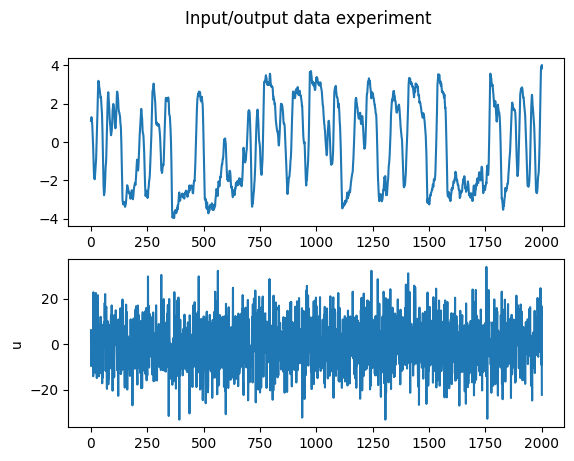

<Figure size 640x480 with 0 Axes>

In [115]:
# Plot the pendulum trajectory together with the input
fig, axs = plt.subplots(2)
fig.suptitle("Input/output data experiment")
axs[0].plot(y_data[:,])
#axs[1].plot(y_data[:,1])
axs[1].plot(u_data)
#axs[1].set(ylabel="theta")
axs[1].set(ylabel="u")
plt.show()

plt.savefig('destination_path.eps', format='eps')

In [116]:

class Net(nn.Module):
    def __init__(self,in_dim,out_dim):
        super().__init__()
        self.config = MambaConfig(d_model=8, n_layers=1)
        self.mamba = nn.Sequential(
            nn.Linear(in_dim,8),
            Mamba(self.config),
            nn.Linear(8,out_dim)
        )
    
    def forward(self,x):
        print("Input Shape:"+str(x.shape))
        x = self.mamba(x)
        return x

In [117]:
trainX.shape

torch.Size([1586, 19])

In [118]:
model = Net(19,10)
model.load_state_dict(torch.load("State_dicts/Test_model_Conv4E8"))


<All keys matched successfully>

In [119]:
testX.unsqueeze(0).shape

torch.Size([1, 1986, 19])

In [120]:
model.eval()
mat = model(testX.unsqueeze(0))
yhat = mat.detach().numpy().squeeze(0)

Input Shape:torch.Size([1, 1986, 19])


In [121]:
def print_shape(module, input, output):
    print(f"Layer: {module.__class__.__name__}, Output shape: {output.shape}")

In [122]:
# Register the hook to a specific layer or to the entire sequential model
for layer in model.mamba: 
    layer.register_forward_hook(print_shape) 
    # or model.seq.register_forward_hook(print_shape) 

input_data = torch.randn(1,89, 15)  # Batch size of 1
output = model(testX.unsqueeze(0)) 

Input Shape:torch.Size([1, 1986, 19])
Layer: Linear, Output shape: torch.Size([1, 1986, 8])
Layer: Mamba, Output shape: torch.Size([1, 1986, 8])
Layer: Linear, Output shape: torch.Size([1, 1986, 10])


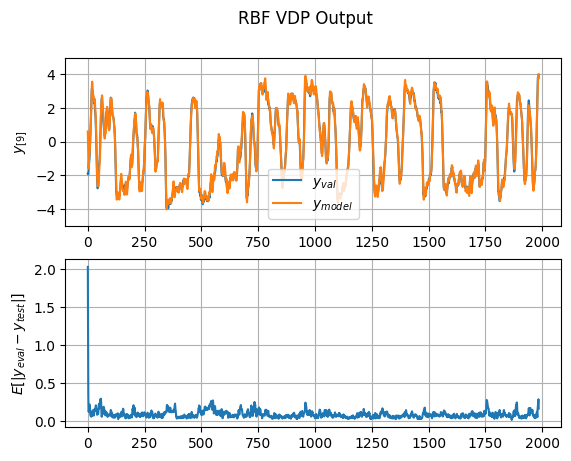

In [123]:
MAE = np.mean(np.abs(yhat - testy.numpy()),1)
RMAE = np.sqrt(MAE)
NRMAE = RMAE/(np.max(testy.numpy())-np.min(testy.numpy()))

fig, axs = plt.subplots(2)
fig.suptitle("RBF VDP Output")
axs[0].plot(testy[:,9], label="$y_{val}$")
axs[0].plot(yhat[:,9], label = "$y_{model}$")
axs[0].legend()
axs[0].grid()
axs[0].set_ylim(-5, 5)

axs[1].plot(MAE)
axs[0].set(ylabel="$y_{[9]}$")
#axs[1].set(ylabel="theta")
axs[1].set(ylabel="$E[|y_{eval}-y_{test}|]$")
axs[1].grid()
plt.show()
fig.savefig("MambaValidationSet.png", format='png')

In [129]:
TotalError = np.sum(MAE)
print("Total Error:"+str(TotalError))

Total Error:175.18048


In [125]:
np.sum(RMSD)

13293.4

In [126]:
np.sum(NRMSD)

1558.1497

In [127]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# Calculate R-squared
r2 = r2_score(testy.numpy(), yhat )

print(f"R-squared on validation set: {r2}")

# Calculate Mean Squared Error
mse = mean_squared_error(testy.numpy(), yhat )

print(f"Mean Squared Error on validation set: {mse}")

R-squared on validation set: 0.996574878692627
Mean Squared Error on validation set: 0.016428934410214424


In [137]:
model.mamba[1].layers.ResidualB

ModuleList(
  (0): ResidualBlock(
    (mixer): MambaBlock(
      (in_proj): Linear(in_features=8, out_features=128, bias=False)
      (conv1d): Conv1d(64, 64, kernel_size=(4,), stride=(1,), padding=(3,), groups=64)
      (x_proj): Linear(in_features=64, out_features=17, bias=False)
      (dt_proj): Linear(in_features=1, out_features=64, bias=True)
      (out_proj): Linear(in_features=64, out_features=8, bias=False)
    )
    (norm): RMSNorm()
  )
)

In [38]:
A = torch.arange(1, 8 + 1, dtype=torch.float32).repeat(8, 1)
A

tensor([[1., 2., 3., 4., 5., 6., 7., 8.],
        [1., 2., 3., 4., 5., 6., 7., 8.],
        [1., 2., 3., 4., 5., 6., 7., 8.],
        [1., 2., 3., 4., 5., 6., 7., 8.],
        [1., 2., 3., 4., 5., 6., 7., 8.],
        [1., 2., 3., 4., 5., 6., 7., 8.],
        [1., 2., 3., 4., 5., 6., 7., 8.],
        [1., 2., 3., 4., 5., 6., 7., 8.]])

In [96]:
torch.exp(model.mamba[1].layers[0].mixer.A_log)

tensor([[0.6212, 1.3023, 1.5381, 1.3366, 1.0804, 1.5131, 1.5552, 1.4813],
        [0.6607, 1.1747, 1.2575, 1.7143, 1.8907, 2.2533, 2.3743, 2.0875],
        [0.9227, 1.5962, 1.2253, 2.1390, 2.4866, 3.1842, 3.0921, 3.5385],
        [0.9289, 2.6873, 0.6743, 2.3465, 1.0316, 3.5606, 2.6422, 3.0314],
        [0.6970, 1.2966, 0.7808, 1.5434, 1.3241, 1.5726, 1.3333, 1.3962],
        [1.0338, 1.8588, 1.9477, 2.2036, 2.3401, 2.5904, 2.2298, 2.3826],
        [0.9223, 1.6891, 1.8000, 3.3530, 2.8848, 4.9474, 4.7839, 5.2889],
        [0.8285, 1.2988, 1.6830, 2.6312, 3.1289, 3.9004, 3.7579, 4.6082],
        [1.4104, 1.1890, 0.8795, 0.7697, 0.4270, 1.3384, 1.2093, 1.3398],
        [0.3564, 1.7901, 0.8471, 1.5925, 1.4117, 1.6366, 1.6627, 1.4630],
        [0.8301, 1.3718, 1.1900, 1.6392, 1.2660, 1.8028, 1.7203, 1.5362],
        [1.2916, 2.1403, 1.3505, 2.0552, 1.5217, 2.3109, 2.2551, 1.9924],
        [0.9183, 1.5833, 1.2443, 1.8408, 1.3996, 1.7848, 1.9651, 1.5335],
        [0.8051, 1.0715, 1.1028, 1.448

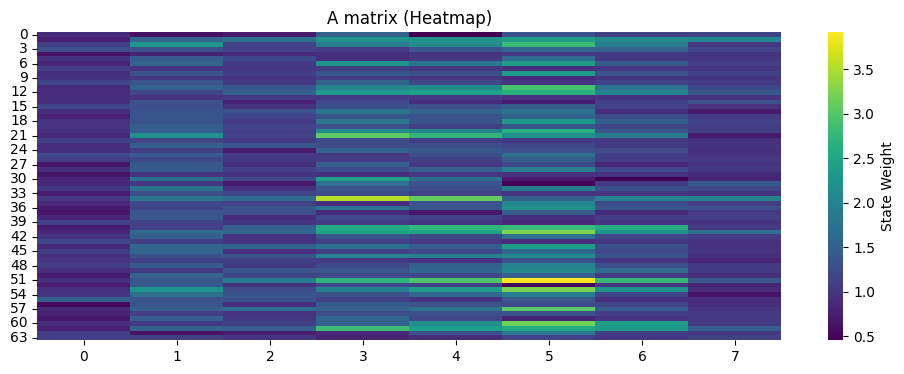

In [138]:
import seaborn as sns
# 2. Heatmap Style Attention Map

plt.figure(figsize=(12, 4))  # Shorter height for heatmap
sns.heatmap(torch.exp(model.mamba[1].layers[0].mixer.A_log).detach().numpy(),  # Reshape for heatmap
            cmap="viridis",  # Choose a suitable colormap
            xticklabels=True,  # Hide x-axis ticks if many time steps
            cbar_kws={'label': 'State Weight'}) # Add a colorbar with label


plt.title("A matrix (Heatmap)")
plt.show()

In [139]:
model.mamba[1].layers[0]

ResidualBlock(
  (mixer): MambaBlock(
    (in_proj): Linear(in_features=8, out_features=128, bias=False)
    (conv1d): Conv1d(64, 64, kernel_size=(4,), stride=(1,), padding=(3,), groups=64)
    (x_proj): Linear(in_features=64, out_features=17, bias=False)
    (dt_proj): Linear(in_features=1, out_features=64, bias=True)
    (out_proj): Linear(in_features=64, out_features=8, bias=False)
  )
  (norm): RMSNorm()
)

In [ ]:
00